## Warehouse Transition Evaluation

This notebook evaluates the operational impact of transitioning part of the spare-parts warehouse population from the traditional manual storage environment into the automated vertical warehouse.

The objective is not to replace the entire warehouse with automation. Instead, the analysis evaluates how selective migration of operationally relevant spare parts affects:

- warehouse workload distribution
- movement concentration
- storage saturation
- operational accessibility
- tray utilisation
- residual manual warehouse structure
- warehouse operational flexibility

The notebook consolidates the outputs generated in the previous feasibility and tray-configuration analyses. The evaluation focuses on:

- manual vs automated warehouse comparison
- movement redistribution
- occupied-volume redistribution
- warehouse saturation
- operational transition KPIs
- residual manual warehouse profile
- warehouse redesign considerations
- operational feasibility conclusions

The analysis remains at warehouse-engineering planning level and does not attempt:

- exact coordinate optimisation
- travel-path simulation
- discrete-event simulation
- PLC-level modelling
- dynamic slotting optimisation

The notebook instead evaluates the operational feasibility and engineering implications of selective warehouse automation.

In [23]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

OUTPUT_DIR = Path("../outputs/powerbi_transition")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_DIR_FEASIBIILTY  = Path("../outputs/automated_feasibility")
INPUT_DIR = Path("../outputs/automated_warehouse")
POWERBI_INPUT_DIR = Path("../outputs/powerbi_operational")

fact_inventory_status = pd.read_csv(
    POWERBI_INPUT_DIR / "fact_inventory_status.csv"
)

automation_candidates = pd.read_csv(
    INPUT_DIR_FEASIBIILTY / "automated_warehouse_candidates.csv"
)

automation_coverage = pd.read_csv(
    INPUT_DIR_FEASIBIILTY / "automated_warehouse_coverage.csv"
)

candidate_tray_allocation = pd.read_csv(
    INPUT_DIR / "candidate_tray_allocation.csv"
)

tray_requirement_summary = pd.read_csv(
    INPUT_DIR / "tray_requirement_summary.csv"
)

warehouse_capacity_summary = pd.read_csv(
    INPUT_DIR / "warehouse_capacity_summary.csv"
)

slotting_priority = pd.read_csv(
    INPUT_DIR / "slotting_priority.csv"
)

warehouse_definition = pd.read_csv(
    INPUT_DIR_FEASIBIILTY / "automated_warehouse_definition.csv"
)

warehouse_dimensioning_summary = pd.read_csv(
    INPUT_DIR_FEASIBIILTY / "warehouse_dimensioning_summary.csv"
)

## Transition Evaluation Context

The warehouse transition strategy follows a selective automation philosophy. The automated warehouse is designed to absorb:

- compact spare parts
- high-movement inventory
- operationally critical items
- storage-intensive picking activity

while the residual manual warehouse continues to manage:

- bulky items
- oversized spare parts
- operationally lower-priority inventory
- manually handled storage categories

This approach improves operational efficiency without requiring full warehouse automation. The following sections evaluate the operational impact of this redistribution.

In [24]:
# parts migrated into the automated warehouse
automated_part_ids = automation_candidates[
    "Part_ID"
].unique()

# automated warehouse population
automated_warehouse = fact_inventory_status[
    fact_inventory_status["Part_ID"].isin(automated_part_ids)
].copy()

# residual manual warehouse population
residual_manual_warehouse = fact_inventory_status[
    ~fact_inventory_status["Part_ID"].isin(automated_part_ids)
].copy()

# original warehouse population
original_warehouse = fact_inventory_status.copy()

## Warehouse Population Summary

This section compares the size of the original warehouse population with the automated warehouse and residual manual warehouse populations after migration.

In [25]:
warehouse_population_summary = pd.DataFrame({
    "Warehouse_Section": [
        "Original warehouse",
        "Automated warehouse",
        "Residual manual warehouse"
    ],
    "SKUs": [
        original_warehouse["Part_ID"].nunique(),
        automated_warehouse["Part_ID"].nunique(),
        residual_manual_warehouse["Part_ID"].nunique()
    ]
})

warehouse_population_summary

,Warehouse_Section,SKUs
0,Original warehouse,1000
1,Automated warehouse,377
2,Residual manual warehouse,623


## Warehouse Structure Before vs After Transition

This section compares the warehouse structure before and after migration into the automated warehouse.

The analysis evaluates:

- SKU distribution
- movement redistribution
- occupied-volume redistribution
- inventory-value redistribution

The objective is to evaluate how much operational activity is absorbed by the automated warehouse.

In [26]:
before_after_summary = pd.DataFrame({
    "Metric": [
        "SKU count",
        "Movement lines 36M",
        "Occupied volume cm3",
        "Inventory value EUR"
    ],

    "Original_Warehouse": [
        original_warehouse["Part_ID"].nunique(),
        original_warehouse["Movement_Lines_36M"].sum(),
        round(original_warehouse["Total_Occupied_Volume_cm3"].sum(), 2),
        round(original_warehouse["Estimated_Inventory_Value_EUR"].sum(), 2)
    ],

    "Automated_Warehouse": [
        automated_warehouse["Part_ID"].nunique(),
        automated_warehouse["Movement_Lines_36M"].sum(),
        round(automated_warehouse["Total_Occupied_Volume_cm3"].sum(), 2),
        round(automated_warehouse["Estimated_Inventory_Value_EUR"].sum(), 2)
    ],

    "Residual_Manual_Warehouse": [
        residual_manual_warehouse["Part_ID"].nunique(),
        residual_manual_warehouse["Movement_Lines_36M"].sum(),
        round(residual_manual_warehouse["Total_Occupied_Volume_cm3"].sum(), 2),
        round(residual_manual_warehouse["Estimated_Inventory_Value_EUR"].sum(), 2)
    ]
})

# Format numbers with commas and 2 decimal places
pd.options.display.float_format = '{:,.2f}'.format

before_after_summary

,Metric,Original_Warehouse,Automated_Warehouse,Residual_Manual_Warehouse
0,SKU count,"1,000.00",377.00,623.00
1,Movement lines 36M,"6,328.00","5,341.00",987.00
2,Occupied volume cm3,"141,087,091.00","8,224,903.00","132,862,188.00"
3,Inventory value EUR,"787,264.15","203,613.46","583,650.69"


## Warehouse Redistribution KPIs

The transition KPIs evaluate how the warehouse operational structure changes after migration into the automated warehouse. 

The indicators measure:

- operational workload transfer
- storage-volume redistribution
- inventory concentration
- remaining manual warehouse workload

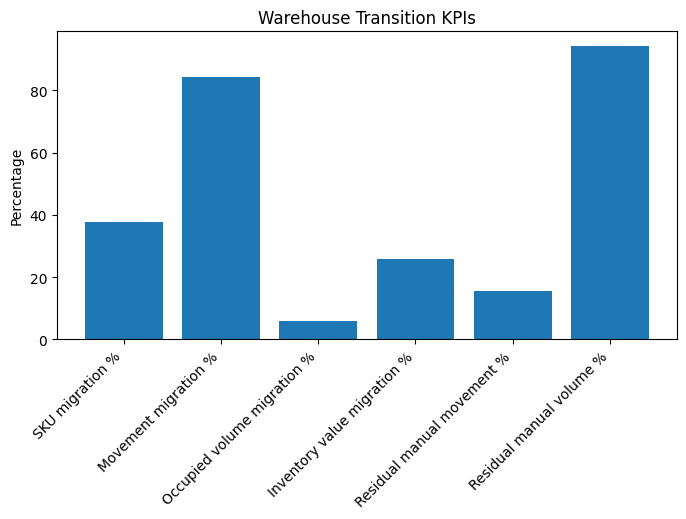

,Transition_KPI,Value
0,SKU migration %,37.70
1,Movement migration %,84.40
2,Occupied volume migration %,5.83
3,Inventory value migration %,25.86
4,Residual manual movement %,15.60
5,Residual manual volume %,94.17


In [27]:
transition_kpis = pd.DataFrame({
    "Transition_KPI": [
        "SKU migration %",
        "Movement migration %",
        "Occupied volume migration %",
        "Inventory value migration %",
        "Residual manual movement %",
        "Residual manual volume %"
    ],

    "Value": [
        round(
            automated_warehouse["Part_ID"].nunique() /
            original_warehouse["Part_ID"].nunique() * 100,
            2
        ),

        round(
            automated_warehouse["Movement_Lines_36M"].sum() /
            original_warehouse["Movement_Lines_36M"].sum() * 100,
            2
        ),

        round(
            automated_warehouse["Total_Occupied_Volume_cm3"].sum() /
            original_warehouse["Total_Occupied_Volume_cm3"].sum() * 100,
            2
        ),

        round(
            automated_warehouse["Estimated_Inventory_Value_EUR"].sum() /
            original_warehouse["Estimated_Inventory_Value_EUR"].sum() * 100,
            2
        ),

        round(
            residual_manual_warehouse["Movement_Lines_36M"].sum() /
            original_warehouse["Movement_Lines_36M"].sum() * 100,
            2
        ),

        round(
            residual_manual_warehouse["Total_Occupied_Volume_cm3"].sum() /
            original_warehouse["Total_Occupied_Volume_cm3"].sum() * 100,
            2
        )
    ]
})

plt.figure(figsize=(8,4))

plt.bar(
    transition_kpis["Transition_KPI"],
    transition_kpis["Value"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Percentage")
plt.title("Warehouse Transition KPIs")

plt.show()

transition_kpis

## Movement Redistribution Analysis

One of the primary objectives of selective warehouse automation is to absorb the highest operational picking activity.

This section evaluates how movement activity is redistributed after migration.

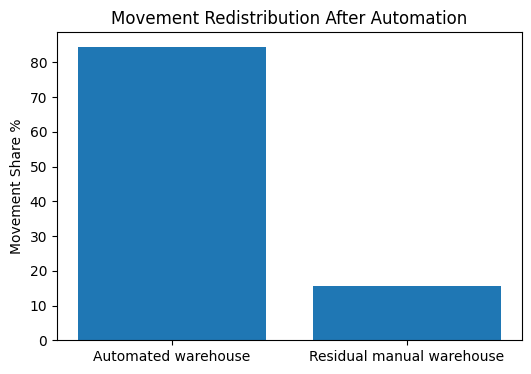

,Warehouse_Section,Movement_Lines_36M,Movement_Share_%
0,Automated warehouse,5341,84.40
1,Residual manual warehouse,987,15.60


In [28]:
movement_distribution = pd.DataFrame({
    "Warehouse_Section": [
        "Automated warehouse",
        "Residual manual warehouse"
    ],

    "Movement_Lines_36M": [
        automated_warehouse["Movement_Lines_36M"].sum(),
        residual_manual_warehouse["Movement_Lines_36M"].sum()
    ]
})

movement_distribution["Movement_Share_%"] = round(
    movement_distribution["Movement_Lines_36M"] /
    movement_distribution["Movement_Lines_36M"].sum() * 100,
    2
)

plt.figure(figsize=(6,4))

plt.bar(
    movement_distribution["Warehouse_Section"],
    movement_distribution["Movement_Share_%"]
)

plt.ylabel("Movement Share %")
plt.title("Movement Redistribution After Automation")

plt.show()

movement_distribution

## Movement Class Redistribution

This section evaluates how movement classes are redistributed between the automated warehouse and the residual manual warehouse.

The objective is to verify whether high-movement inventory is effectively concentrated inside the automated storage environment.

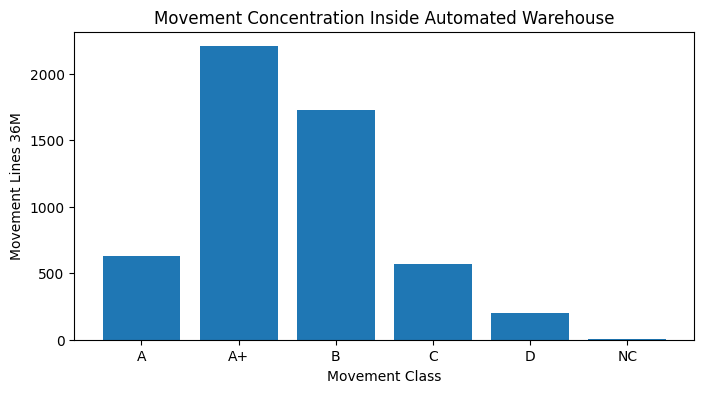

,Movement_Class,Automated_SKUs,Automated_Movement_Lines
0,A,8,633
1,A+,8,2207
2,B,51,1726
3,C,95,571
4,D,172,200
5,NC,43,4


In [29]:
movement_class_distribution = (
    automation_candidates
    .groupby("Movement_Class")
    .agg(
        Automated_SKUs=("Part_ID", "count"),
        Automated_Movement_Lines=("Movement_Lines_36M", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(8,4))

plt.bar(
    movement_class_distribution["Movement_Class"],
    movement_class_distribution["Automated_Movement_Lines"]
)

plt.xlabel("Movement Class")
plt.ylabel("Movement Lines 36M")
plt.title("Movement Concentration Inside Automated Warehouse")

plt.show()

movement_class_distribution

## Residual Manual Warehouse Profile

After migration of operationally intensive inventory into the automated warehouse, the residual manual warehouse becomes increasingly composed of:

- bulky spare parts
- oversized inventory
- operationally lower-priority items
- lower-frequency storage activity

In [30]:
manual_profile_summary = pd.DataFrame({
    "Metric": [
        "Residual manual SKUs",
        "Residual manual movement lines",
        "Residual manual occupied volume cm3",
        "Residual manual inventory value EUR",
        "Average movement lines per residual SKU"
    ],

    "Value": [
        residual_manual_warehouse["Part_ID"].nunique(),
        residual_manual_warehouse["Movement_Lines_36M"].sum(),
        round(
            residual_manual_warehouse[
                "Total_Occupied_Volume_cm3"
            ].sum(),
            2
        ),
        round(
            residual_manual_warehouse[
                "Estimated_Inventory_Value_EUR"
            ].sum(),
            2
        ),
        round(
            residual_manual_warehouse[
                "Movement_Lines_36M"
            ].mean(),
            2
        )
    ]
})

# Format numbers with commas and 2 decimal places
pd.options.display.float_format = '{:,.2f}'.format

manual_profile_summary

,Metric,Value
0,Residual manual SKUs,623.00
1,Residual manual movement lines,987.00
2,Residual manual occupied volume cm3,"132,862,188.00"
3,Residual manual inventory value EUR,"583,650.69"
4,Average movement lines per residual SKU,1.58


## Automated Warehouse Operational Profile

The automated warehouse is evaluated using the tray-allocation and warehouse-capacity outputs generated in the previous notebook.

The objective is to evaluate:

- tray utilisation
- warehouse saturation
- remaining future capacity
- operational movement concentration
- tray-family distribution

In [31]:
warehouse_capacity_summary

tray_requirement_summary

,Proposed_Tray_Type,Parts,Compartments_Per_Tray,Estimated_Compartments_Required,Total_Required_Volume_cm3,Total_Movement_Lines,Compartment_Volume_cm3,Estimated_Trays_Required,Estimated_Available_Tray_Volume_cm3,Estimated_Compartment_Utilisation_%
0,D,117,16,117,2123719,2301,"14,000.00",8.00,"1,792,000.00",118.51
1,B,227,50,227,773063,1989,"4,480.00",5.00,"1,120,000.00",69.02
2,E,25,8,25,878275,274,"28,000.00",4.00,"896,000.00",98.02
3,G,5,4,5,659194,221,"56,000.00",2.00,"448,000.00",147.14
4,Ver,2,1,2,3543485,528,"224,000.00",2.00,"448,000.00",790.96
5,F,1,2,1,247167,28,"112,000.00",1.00,"224,000.00",110.34


## Tray Family Distribution

This section evaluates how the automated warehouse capacity is distributed across tray families.

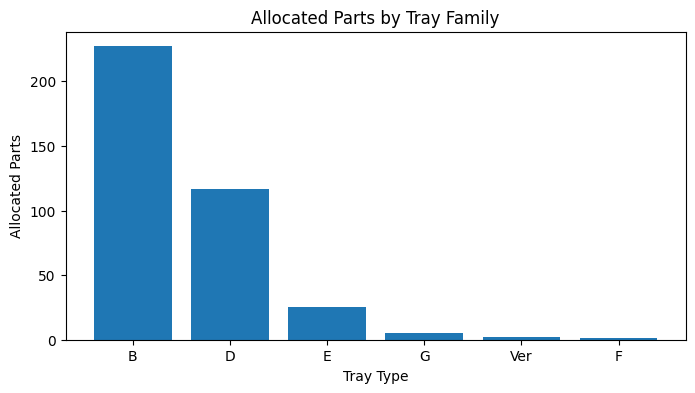

,Proposed_Tray_Type,Parts,Total_Movement_Lines
0,B,227,1989
1,D,117,2301
2,E,25,274
4,G,5,221
5,Ver,2,528
3,F,1,28


In [32]:
tray_family_distribution = (
    candidate_tray_allocation
    .groupby("Proposed_Tray_Type")
    .agg(
        Parts=("Part_ID", "count"),
        Total_Movement_Lines=("Movement_Lines_36M", "sum")
    )
    .reset_index()
    .sort_values("Parts", ascending=False)
)

plt.figure(figsize=(8,4))

plt.bar(
    tray_family_distribution["Proposed_Tray_Type"],
    tray_family_distribution["Parts"]
)

plt.xlabel("Tray Type")
plt.ylabel("Allocated Parts")
plt.title("Allocated Parts by Tray Family")

plt.show()

tray_family_distribution

## Slotting Priority Review

The automated warehouse follows a movement-priority slotting philosophy.

High-movement tray families should be positioned closer to the picking bays to improve:

- accessibility
- retrieval responsiveness
- operator waiting time
- picking efficiency

In [33]:
slotting_priority

,Proposed_Tray_Type,Parts,Total_Movement_Lines,Suggested_Position_Priority
0,D,117,2301,1
1,B,227,1989,2
2,Ver,2,528,3
3,E,25,274,4
4,G,5,221,5
5,F,1,28,6


## Warehouse Saturation Evaluation

The automated warehouse is intentionally dimensioned below full saturation.

Maintaining spare capacity supports:

- future inventory migration
- operational flexibility
- tray reconfiguration
- warehouse growth
- future slotting optimisation

In [34]:
warehouse_saturation_review = pd.DataFrame({
    "Metric": [
        "Available trays",
        "Estimated used trays",
        "Remaining tray capacity",
        "Tray saturation %",
        "Warehouse volume saturation %"
    ],

    "Value": [
        warehouse_capacity_summary.loc[
            warehouse_capacity_summary["Metric"] == "Available trays",
            "Value"
        ].values[0],

        warehouse_capacity_summary.loc[
            warehouse_capacity_summary["Metric"] == "Used trays",
            "Value"
        ].values[0],

        warehouse_capacity_summary.loc[
            warehouse_capacity_summary["Metric"] == "Remaining trays",
            "Value"
        ].values[0],

        warehouse_capacity_summary.loc[
            warehouse_capacity_summary["Metric"] == "Tray saturation %",
            "Value"
        ].values[0],

        warehouse_capacity_summary.loc[
            warehouse_capacity_summary["Metric"] == "Warehouse volume saturation %",
            "Value"
        ].values[0]
    ]
})

warehouse_saturation_review

,Metric,Value
0,Available trays,53.00
1,Estimated used trays,22.00
2,Remaining tray capacity,31.00
3,Tray saturation %,41.51
4,Warehouse volume saturation %,40.86


## Operational Transition Assessment

The transition analysis indicates that selective warehouse automation significantly redistributes operational activity while maintaining manageable warehouse saturation.

The automated warehouse absorbs:

- a relatively limited share of total SKUs
- most operational picking activity
- compact high-frequency spare parts
- operationally intensive inventory flows

At the same time, the residual manual warehouse retains:

- bulky items
- oversized storage categories
- lower-frequency inventory
- operationally lower-priority spare parts

The warehouse transition therefore improves:

- operational concentration
- storage accessibility
- picking responsiveness
- storage-density efficiency
- warehouse-space utilisation

without requiring full warehouse automation.

## Final Operational Conclusions

The warehouse transition evaluation indicates that selective migration into the automated warehouse is operationally feasible and coherent with the warehouse-engineering objectives defined in the project.

The analysis demonstrates that:

- a relatively limited share of SKUs generates most warehouse activity
- compact high-movement spare parts are highly compatible with tray-based automation
- selective migration significantly reduces manual operational workload
- the automated warehouse achieves strong movement coverage while maintaining controlled saturation
- residual manual storage remains necessary for bulky and operationally lower-priority inventory
- tray standardisation supports maintainability and operational practicality
- movement-priority slotting improves accessibility and operational responsiveness
- maintaining spare warehouse capacity improves long-term operational flexibility

The transition therefore improves operational warehouse efficiency while preserving implementation practicality and future warehouse scalability.

In [35]:
transition_kpis.to_csv(
    OUTPUT_DIR / "warehouse_transition_kpis.csv",
    index=False
)

before_after_summary.to_csv(
    OUTPUT_DIR / "warehouse_before_after_summary.csv",
    index=False
)

movement_distribution.to_csv(
    OUTPUT_DIR / "movement_distribution_summary.csv",
    index=False
)

movement_class_distribution.to_csv(
    OUTPUT_DIR / "movement_class_distribution.csv",
    index=False
)

manual_profile_summary.to_csv(
    OUTPUT_DIR / "residual_manual_warehouse_profile.csv",
    index=False
)

tray_family_distribution.to_csv(
    OUTPUT_DIR / "tray_family_distribution.csv",
    index=False
)

warehouse_saturation_review.to_csv(
    OUTPUT_DIR / "warehouse_saturation_review.csv",
    index=False
)